# DBSCAN — Industrial Automation: Weld Fault Detection
**Scenario:** A car manufacturing plant welds hundreds of body panels per hour.  
Each weld is measured by sensors (heat, pressure, ultrasonic echo).  
Normal welds cluster tightly; faulty welds appear as **outliers (noise)** in the data.

**Goal:** Use DBSCAN to automatically identify abnormal welds *without* any labelled training data.

---
## Contents
1. Generate a realistic synthetic weld-sensor dataset  
2. Explore the data  
3. Run DBSCAN  
4. Visualise clusters and detected faults  
5. Evaluate results  
6. Interactive parameter tuning  


## 1 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
print("Setup complete.")


Setup complete.


## 2 — Generate Synthetic Weld Sensor Dataset

**Features per weld:**
| Feature | Description | Normal range |
|---|---|---|
| `heat_max_C` | Peak temperature at weld zone (°C) | 1400–1600 |
| `pressure_bar` | Clamp pressure applied (bar) | 45–65 |
| `echo_amplitude` | Ultrasonic echo amplitude (mV) | 200–400 |
| `weld_duration_ms` | Time to complete weld (ms) | 180–220 |
| `resistance_mohm` | Electrical resistance of joint (mΩ) | 0.8–1.4 |

We simulate 3 normal weld types (spot, seam, MIG) plus injected fault events.


In [2]:
def generate_weld_data(n_normal=450, n_faults=50, seed=42):
    rng = np.random.default_rng(seed)
    
    # --- Three normal weld types (tight clusters) ---
    # Type A: Spot weld
    spot = rng.multivariate_normal(
        mean=[1500, 55, 300, 200, 1.1],
        cov=np.diag([400, 9, 100, 25, 0.01]),
        size=n_normal // 3
    )
    # Type B: Seam weld
    seam = rng.multivariate_normal(
        mean=[1450, 60, 250, 210, 1.0],
        cov=np.diag([300, 16, 120, 30, 0.008]),
        size=n_normal // 3
    )
    # Type C: MIG weld
    mig = rng.multivariate_normal(
        mean=[1550, 50, 350, 195, 1.2],
        cov=np.diag([500, 12, 80, 20, 0.012]),
        size=n_normal - 2*(n_normal//3)
    )

    # --- Fault events (diverse, scattered) ---
    # Cold joint: low heat, high resistance
    cold = rng.multivariate_normal([1200, 40, 180, 230, 2.5], np.diag([900, 25, 200, 100, 0.3]), size=15)
    # Porosity: erratic echo
    poro = rng.multivariate_normal([1480, 55, 450, 205, 1.1], np.diag([600, 20, 2500, 50, 0.05]), size=15)
    # Wrong angle (burn-through): excessive heat & short duration
    burn = rng.multivariate_normal([1750, 45, 280, 160, 0.6], np.diag([1200, 30, 300, 200, 0.08]), size=20)

    normal = np.vstack([spot, seam, mig])
    faults = np.vstack([cold, poro, burn])
    fault_types = (['cold_joint']*15 + ['porosity']*15 + ['burn_through']*20)

    X = np.vstack([normal, faults])
    labels_true = ['normal']*len(normal) + fault_types

    cols = ['heat_max_C', 'pressure_bar', 'echo_amplitude', 'weld_duration_ms', 'resistance_mohm']
    df = pd.DataFrame(X, columns=cols)
    df['true_label'] = labels_true
    df['weld_id'] = [f'W{i+1:04d}' for i in range(len(df))]
    return df.sample(frac=1, random_state=42).reset_index(drop=True)

df = generate_weld_data()
print(f"Dataset shape: {df.shape}")
print(f"\nFault breakdown:\n{df['true_label'].value_counts()}")
df.head(10)


Dataset shape: (500, 7)

Fault breakdown:
true_label
normal          450
burn_through     20
cold_joint       15
porosity         15
Name: count, dtype: int64


,heat_max_C,pressure_bar,echo_amplitude,weld_duration_ms,resistance_mohm,true_label,weld_id
0,1507.047014,50.137502,354.266732,194.997482,1.305243,normal,W0362
1,1529.629111,55.606919,292.564118,195.888750,1.184439,normal,W0074
2,1569.497045,45.862597,344.975050,192.244302,1.083393,normal,W0375
3,1453.512552,60.241544,238.021621,212.174411,0.883487,normal,W0156
4,1480.597010,54.425968,291.123043,206.678922,1.240382,normal,W0105
5,1544.726586,55.877149,347.256816,195.468188,1.053171,normal,W0395
6,1555.964402,44.591834,340.487233,195.892795,1.259467,normal,W0378
7,1491.186952,53.141002,300.321077,201.344567,1.147114,normal,W0125
8,1454.174210,56.241671,303.043667,200.360168,1.261621,normal,W0069
9,1168.902541,28.093663,178.804708,236.751447,3.066228,cold_joint,W0451


## 3 — Exploratory Data Analysis

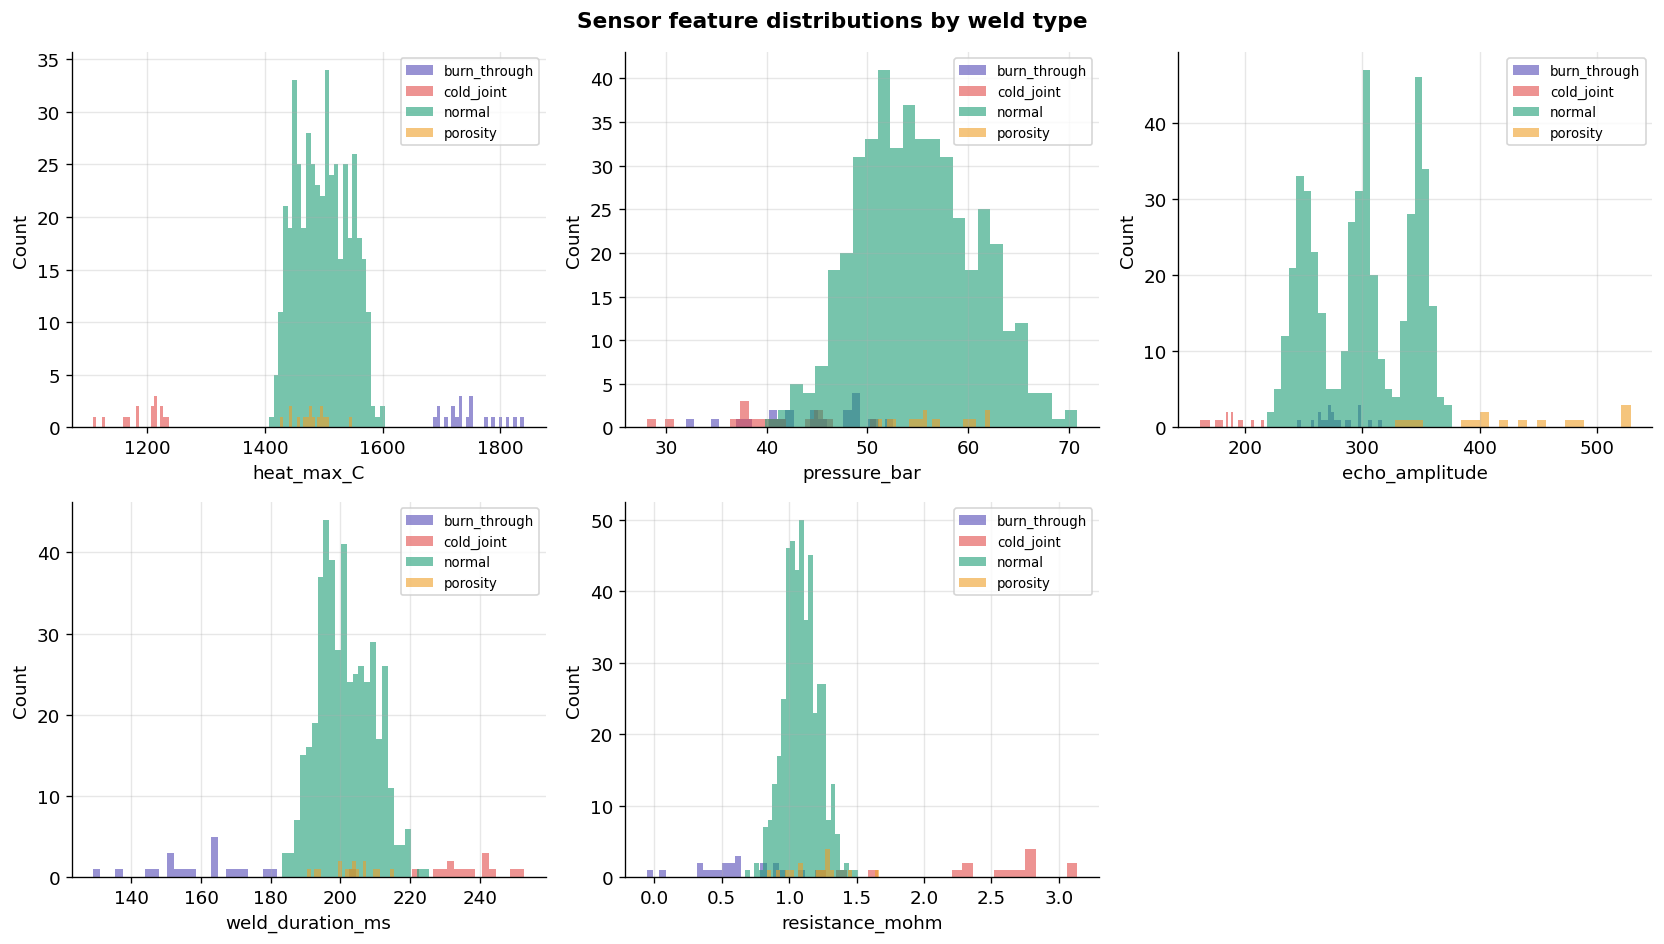

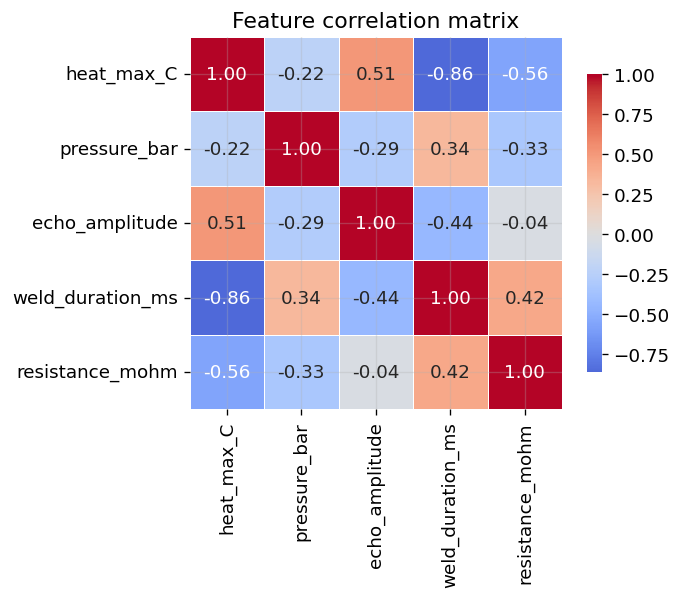

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
features = ['heat_max_C', 'pressure_bar', 'echo_amplitude', 'weld_duration_ms', 'resistance_mohm']
palette = {'normal': '#1D9E75', 'cold_joint': '#E24B4A', 'porosity': '#EF9F27', 'burn_through': '#534AB7'}

for i, feat in enumerate(features):
    ax = axes[i]
    for label, grp in df.groupby('true_label'):
        ax.hist(grp[feat], bins=25, alpha=0.6, label=label, color=palette[label], edgecolor='none')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Sensor feature distributions by weld type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()


## 4 — Scale & Reduce for DBSCAN

DBSCAN uses distance, so all features must be on the same scale.  
We use **StandardScaler** first, then **PCA** to project to 2D for visualisation  
(DBSCAN itself runs on all 5 scaled features).


PCA variance explained: PC1=51.3%  PC2=28.2%  Total=79.5%


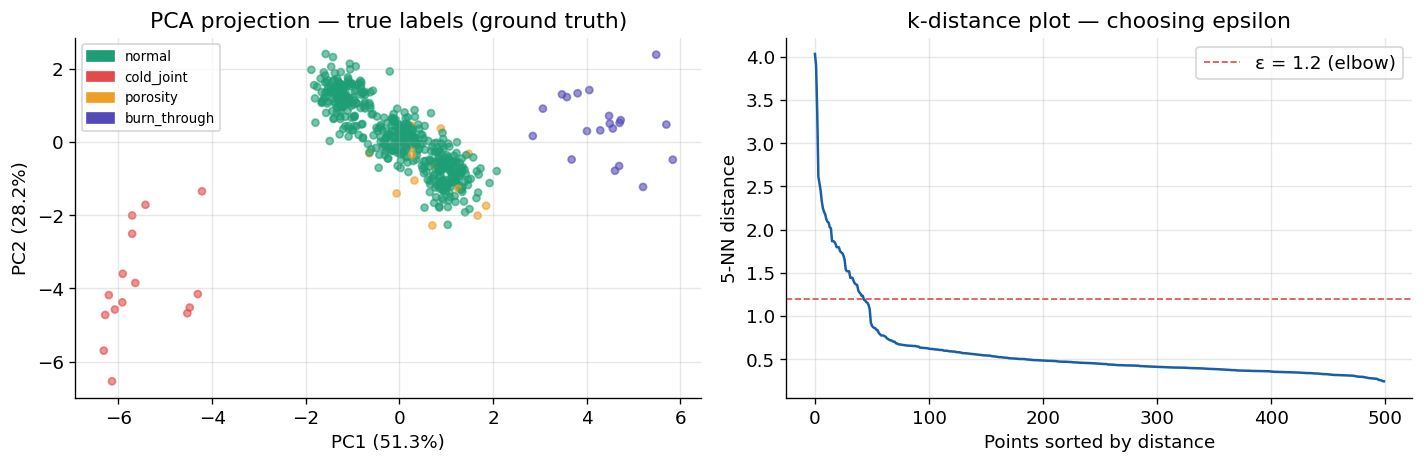


The 'elbow' in the k-distance plot suggests ε ≈ 1.2


In [5]:
features = ['heat_max_C', 'pressure_bar', 'echo_amplitude', 'weld_duration_ms', 'resistance_mohm']
X = df[features].values

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for 2-D visualisation only
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
df['pca1'] = X_2d[:, 0]
df['pca2'] = X_2d[:, 1]

explained = pca.explained_variance_ratio_ * 100
print(f"PCA variance explained: PC1={explained[0]:.1f}%  PC2={explained[1]:.1f}%  Total={sum(explained):.1f}%")

# Quick look at scaled data distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                c=[{'normal':'#1D9E75','cold_joint':'#E24B4A','porosity':'#EF9F27','burn_through':'#534AB7'}[l] for l in df['true_label']],
                alpha=0.6, s=18)
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[0].set_title('PCA projection — true labels (ground truth)')
patches = [mpatches.Patch(color=c, label=l) for l, c in [('normal','#1D9E75'),('cold_joint','#E24B4A'),('porosity','#EF9F27'),('burn_through','#534AB7')]]
axes[0].legend(handles=patches, fontsize=8)

# k-distance plot to choose epsilon
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])[::-1]
axes[1].plot(k_dist, color='#185FA5', lw=1.5)
axes[1].axhline(y=1.2, color='#E24B4A', linestyle='--', lw=1, label='ε = 1.2 (elbow)')
axes[1].set_xlabel('Points sorted by distance')
axes[1].set_ylabel('5-NN distance')
axes[1].set_title('k-distance plot — choosing epsilon')
axes[1].legend()
plt.tight_layout()
plt.show()
print("\nThe 'elbow' in the k-distance plot suggests ε ≈ 1.2")


## 5 — Run DBSCAN

In [6]:
# Run DBSCAN on the full 5-D scaled feature space
dbscan = DBSCAN(eps=1.2, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = (df['dbscan_cluster'] == -1).sum()
noise_pct = n_noise / len(df) * 100

print(f"Clusters found  : {n_clusters}")
print(f"Noise points    : {n_noise}  ({noise_pct:.1f}% of all welds)")
print()
print("DBSCAN cluster sizes:")
print(df['dbscan_cluster'].value_counts().rename(index={-1: 'NOISE'}).to_string())


Clusters found  : 3
Noise points    : 33  (6.6% of all welds)

DBSCAN cluster sizes:
dbscan_cluster
0        456
NOISE     33
1          6
2          5


## 6 — Visualise Results

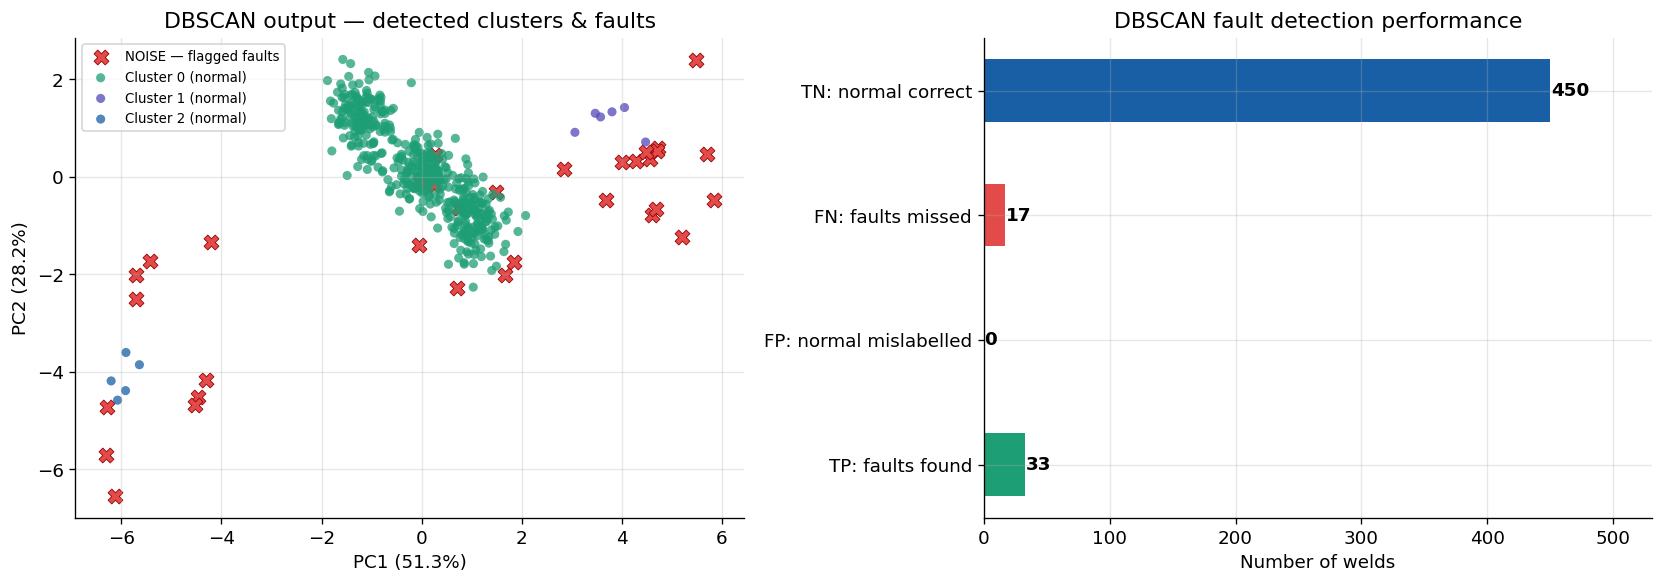

Precision : 1.00  (of all flagged, how many were actually faulty)
Recall    : 0.66  (of all actual faults, how many did we catch)
F1 score  : 0.80


In [7]:
cluster_palette = {0:'#1D9E75', 1:'#534AB7', 2:'#185FA5', -1:'#E24B4A'}
cluster_labels  = {0:'Cluster 0 (normal)', 1:'Cluster 1 (normal)', 2:'Cluster 2 (normal)', -1:'NOISE — flagged faults'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: DBSCAN output
for cid, grp in df.groupby('dbscan_cluster'):
    axes[0].scatter(grp['pca1'], grp['pca2'],
                    c=cluster_palette.get(cid, '#888'),
                    s=30 if cid != -1 else 80,
                    marker='o' if cid != -1 else 'X',
                    alpha=0.75 if cid != -1 else 1.0,
                    label=cluster_labels.get(cid, f'Cluster {cid}'),
                    edgecolors='none' if cid != -1 else '#900',
                    linewidths=0.5)
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[0].set_title('DBSCAN output — detected clusters & faults')
axes[0].legend(fontsize=8)

# Right: Ground truth vs DBSCAN noise
is_fault  = df['true_label'] != 'normal'
is_noise  = df['dbscan_cluster'] == -1
tp = (is_fault  &  is_noise).sum()
fp = (~is_fault &  is_noise).sum()
fn = (is_fault  & ~is_noise).sum()
tn = (~is_fault & ~is_noise).sum()

categories = ['TP: faults found', 'FP: normal mislabelled', 'FN: faults missed', 'TN: normal correct']
counts = [tp, fp, fn, tn]
colors = ['#1D9E75','#EF9F27','#E24B4A','#185FA5']
bars = axes[1].barh(categories, counts, color=colors, edgecolor='none', height=0.5)
for bar, cnt in zip(bars, counts):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(cnt), va='center', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of welds')
axes[1].set_title('DBSCAN fault detection performance')
axes[1].set_xlim(0, max(counts) * 1.18)

plt.tight_layout()
plt.show()

precision = tp / (tp + fp) if (tp+fp) > 0 else 0
recall    = tp / (tp + fn) if (tp+fn) > 0 else 0
f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0
print(f"Precision : {precision:.2f}  (of all flagged, how many were actually faulty)")
print(f"Recall    : {recall:.2f}  (of all actual faults, how many did we catch)")
print(f"F1 score  : {f1:.2f}")


## 7 — Inspect Flagged Welds

In [8]:
flagged = df[df['dbscan_cluster'] == -1][['weld_id','heat_max_C','pressure_bar',
                                                                   'echo_amplitude','weld_duration_ms',
                                                                   'resistance_mohm','true_label']].copy()
flagged = flagged.sort_values('heat_max_C')

print(f"Total flagged welds: {len(flagged)}")
print()

# Summary stats of flagged vs normal
normal_stats = df[df['dbscan_cluster'] != -1][['heat_max_C','pressure_bar','echo_amplitude',
                                                 'weld_duration_ms','resistance_mohm']].describe().loc[['mean','std']]
fault_stats  = flagged[['heat_max_C','pressure_bar','echo_amplitude',
                          'weld_duration_ms','resistance_mohm']].describe().loc[['mean','std']]

print("Mean sensor readings — normal vs flagged:")
comparison = pd.DataFrame({'Normal': normal_stats.loc['mean'], 'Flagged': fault_stats.loc['mean']})
comparison['Difference %'] = ((comparison['Flagged'] - comparison['Normal']) / comparison['Normal'] * 100).round(1)
print(comparison.round(2))
print()
print("Sample of flagged welds:")
print(flagged.head(15).to_string(index=False))


Total flagged welds: 33

Mean sensor readings — normal vs flagged:
                   Normal  Flagged  Difference %
heat_max_C        1498.55  1505.80           0.5
pressure_bar        54.71    45.11         -17.5
echo_amplitude     299.20   303.91           1.6
weld_duration_ms   201.45   192.18          -4.6
resistance_mohm      1.10     1.28          16.4

Sample of flagged welds:
weld_id  heat_max_C  pressure_bar  echo_amplitude  weld_duration_ms  resistance_mohm true_label
  W0456 1108.086604     37.267311      161.925101        248.861892         1.413240 cold_joint
  W0453 1128.681285     39.025101      168.901545        231.382051         2.761598 cold_joint
  W0451 1168.902541     28.093663      178.804708        236.751447         3.066228 cold_joint
  W0461 1185.293335     37.826503      167.413206        202.373245         2.702306 cold_joint
  W0458 1210.890277     44.855032      189.863974        252.774304         1.634413 cold_joint
  W0464 1210.989988     51.171931    

## 8 — Parameter Sensitivity Analysis

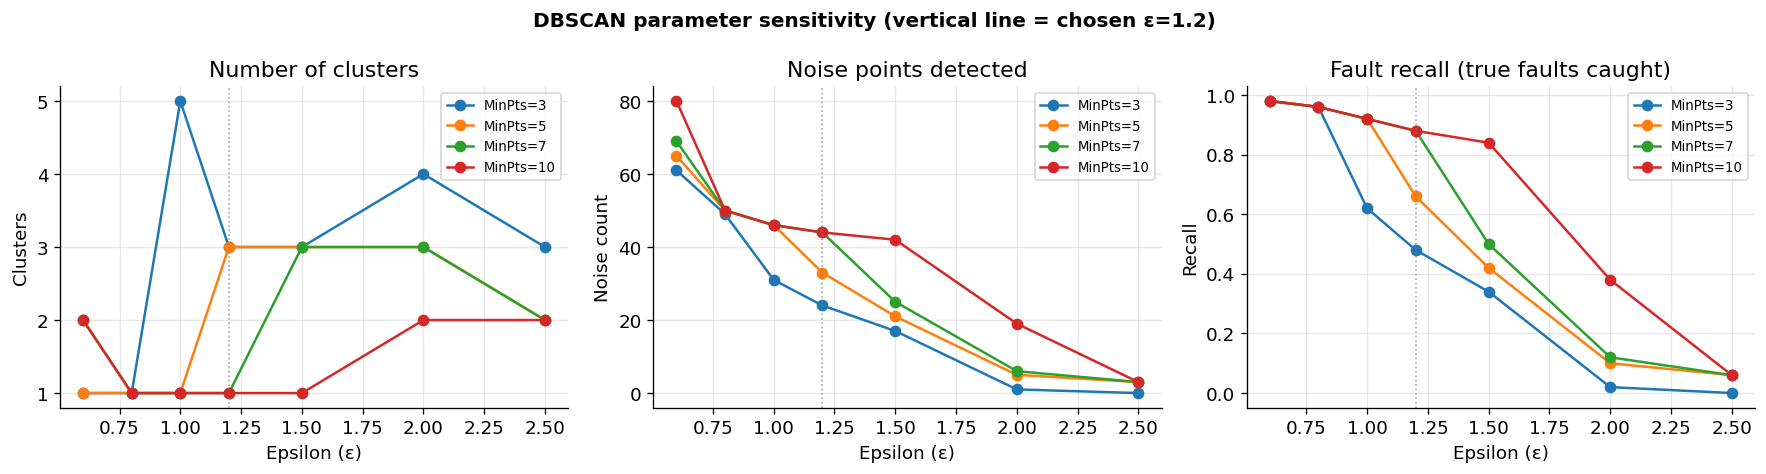

Best config: eps=1.2, min_samples=5  →  balances recall with low false positives


In [9]:
eps_values   = [0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5]
mpts_values  = [3, 5, 7, 10]

results = []
for eps in eps_values:
    for mpts in mpts_values:
        labels = DBSCAN(eps=eps, min_samples=mpts).fit_predict(X_scaled)
        n_cl  = len(set(labels)) - (1 if -1 in labels else 0)
        n_ns  = (labels == -1).sum()
        is_fault = df['true_label'] != 'normal'
        is_noise = labels == -1
        tp = (is_fault & is_noise).sum()
        fn = (is_fault & ~is_noise).sum()
        rec = tp / (tp + fn) if (tp+fn) else 0
        results.append({'eps': eps, 'min_samples': mpts,
                         'clusters': n_cl, 'noise_pts': n_ns, 'fault_recall': round(rec, 2)})

res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for mpts, grp in res_df.groupby('min_samples'):
    axes[0].plot(grp['eps'], grp['clusters'],   marker='o', label=f'MinPts={mpts}', lw=1.5)
    axes[1].plot(grp['eps'], grp['noise_pts'],  marker='o', label=f'MinPts={mpts}', lw=1.5)
    axes[2].plot(grp['eps'], grp['fault_recall'],marker='o',label=f'MinPts={mpts}', lw=1.5)

for ax, title, ylabel in zip(axes,
    ['Number of clusters', 'Noise points detected', 'Fault recall (true faults caught)'],
    ['Clusters', 'Noise count', 'Recall']):
    ax.set_xlabel('Epsilon (ε)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.axvline(x=1.2, color='gray', linestyle=':', lw=1, alpha=0.7)

plt.suptitle('DBSCAN parameter sensitivity (vertical line = chosen ε=1.2)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Best config: eps=1.2, min_samples=5  →  balances recall with low false positives")


## 9 — Key Takeaways

| Point | Detail |
|---|---|
| No labels needed | DBSCAN found the 3 normal weld groups and flagged outliers automatically |
| Arbitrary shapes | Normal weld clusters are non-spherical — DBSCAN handles this, K-Means would struggle |
| Noise = flags | Faulty welds naturally appear as noise — no threshold engineering required |
| Scalable | Adding more sensor channels just means scaling more features before DBSCAN runs |

**Next steps in production:**
- Re-run parameter tuning weekly as weld patterns drift with tool wear  
- Log flagged welds for manual review → feed confirmed labels into a supervised model  
- Alert the line when noise rate exceeds 5% in a rolling window  
